# Bank Marketing Prediction

## Business Understanding

A bank conducts telemarketing campaigns to promote term deposit subscriptions. Contacting every customer is costly and often inefficient.

The objective of this project is to build a machine learning model that predicts whether a customer will subscribe to a term deposit product. By identifying high-potential customers, the bank can improve campaign effectiveness and allocate marketing resources more efficiently.

# 1. Import Library

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Utilities
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)

# Visualization Style
sns.set_style("whitegrid")

# 2. Data Loading

In [55]:
# Load dataset
df = pd.read_csv("data/bank-full.csv", sep=";")

# Display first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Dataset Overview

The Bank Marketing Dataset contains customer demographic information, financial attributes, and records of previous marketing campaigns conducted by a banking institution.

The target variable is `y`, which indicates whether a customer subscribed to a term deposit product (`yes`) or not (`no`).

This dataset will be used to identify patterns associated with successful subscriptions and to build a predictive classification model.


# 3. Data Understanding

In [3]:
# Dataset dimensions
df.shape

(45211, 17)

The dataset contains 45,211 customer records and 17 features, providing a substantial amount of information for exploratory analysis and predictive modeling.

With more than 45,000 observations, the dataset is large enough to capture customer behavior patterns and support the development of a reliable machine learning model for term deposit subscription prediction.

In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Dataset Information

The dataset contains 45,211 observations and 17 columns. All columns contain 45,211 non-null values, indicating that there are no missing values recorded as null (`NaN`).

The dataset consists of:
- 7 numerical features (`age`, `balance`, `day`, `duration`, `campaign`, `pdays`, and `previous`)
- 10 categorical features (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`, and `y`)

The target variable is `y`, which indicates whether a customer subscribed to a term deposit product. The combination of demographic, financial, and campaign-related features provides a strong foundation for predictive modeling.

In [5]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

### Missing Values Analysis

No missing values were detected in the dataset, as all features contain complete records across the 45,211 observations.

However, some categorical variables may contain the value `"unknown"`, which could represent unavailable or unrecorded information. This will be investigated further during the exploratory data analysis and preprocessing stages.

In [6]:
# Check duplicate rows
df.duplicated().sum()

0

### Duplicate Values Analysis

No duplicate records were found in the dataset. This indicates that each observation represents a unique customer interaction and no duplicate removal is required before proceeding with the analysis.

In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Statistical Summary

Several interesting observations can be identified from the numerical features:

- The average customer age is approximately 41 years, with ages ranging from 18 to 95 years.
- Customer account balances vary significantly, ranging from -8,019 to 102,127, indicating the presence of potential outliers.
- The average call duration is approximately 258 seconds, although some calls lasted as long as 4,918 seconds.
- Most customers were contacted only a few times during the campaign, with a median of 2 contacts.
- The `pdays` feature contains many values of `-1`, suggesting that a large proportion of customers had not been contacted in previous campaigns.
- Several numerical features exhibit substantial variability, which may require further investigation through exploratory data analysis.

In [8]:
# Statistical summary for categorical features
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


### Categorical Features Summary

The dataset contains 10 categorical features with varying numbers of unique categories.

Several notable observations include:

- The most common occupation is `blue-collar`.
- Most customers are `married`.
- The majority of customers have a `secondary` education level.
- Most customers do not have credit in default.
- Housing loans are more common than personal loans.
- The most frequently used contact method is `cellular`.
- The majority of previous campaign outcomes are recorded as `unknown`.
- The target variable is dominated by the `no` class, suggesting a potential class imbalance problem.


# 4. Exploratory Data Analysis (EDA)

## Target Variable Distribution

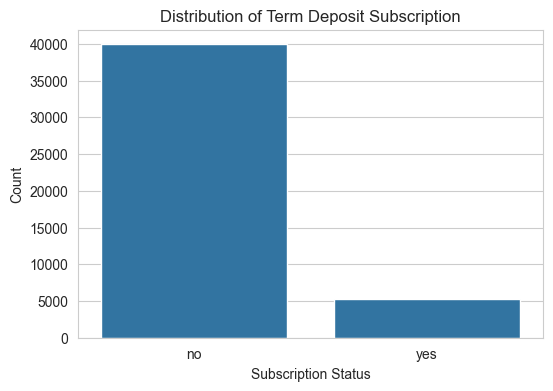

In [9]:
# Target distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='y'
)

plt.title('Distribution of Term Deposit Subscription')
plt.xlabel('Subscription Status')
plt.ylabel('Count')

plt.show()

In [10]:
# Target percentage
df['y'].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

### Insight: Target Variable Distribution

The target variable is highly imbalanced. Approximately **88.3%** of customers did not subscribe to a term deposit, while only **11.7%** subscribed.

This indicates that successful subscriptions are relatively rare events. As a result, relying solely on accuracy may be misleading because a model could achieve high accuracy by simply predicting the majority class.

Therefore, additional evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC should be considered during model evaluation to ensure the model can effectively identify potential subscribers.

## Customer Age Distribution

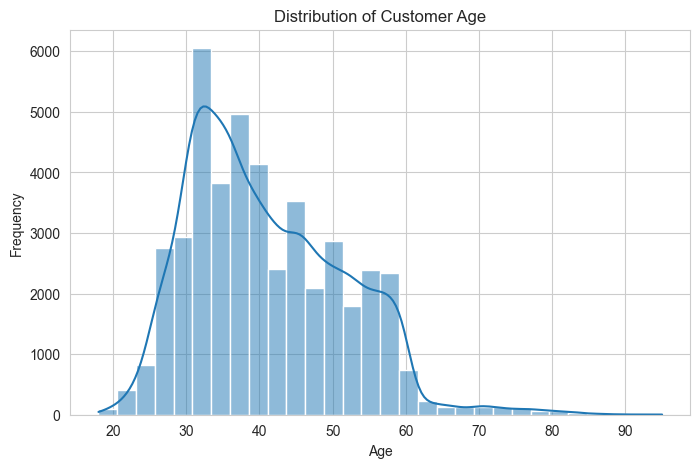

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

In [12]:
df['age'].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

### Insight: Customer Age Distribution

The customer age distribution is slightly right-skewed, with most customers falling between 30 and 50 years old.

The average customer age is approximately 41 years, while the median age is 39 years, indicating that the dataset is primarily composed of working-age adults. A small number of older customers above 60 years old are also present, creating a long tail in the distribution.

This suggests that the bank's marketing campaigns primarily target economically active individuals who are more likely to have stable income sources and financial products such as savings accounts or term deposits.

## Age vs Term Deposit Subscription

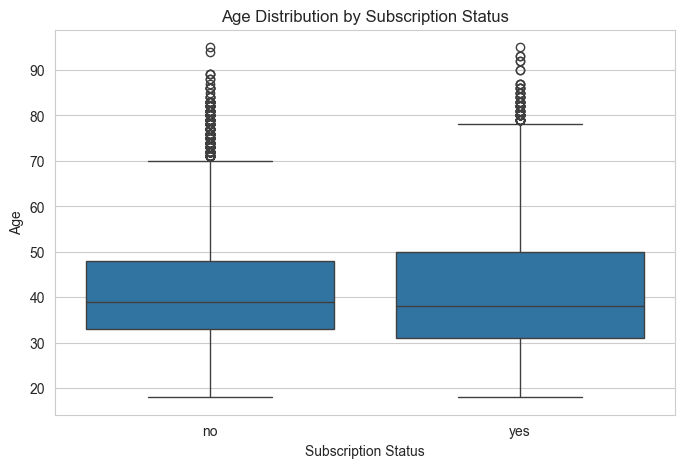

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='y',
    y='age'
)

plt.title('Age Distribution by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Age')

plt.show()

In [14]:
df.groupby('y')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,40.838986,10.172662,18.0,33.0,39.0,48.0,95.0
yes,5289.0,41.670070,13.497781,18.0,31.0,38.0,50.0,95.0


### Insight: Age vs Term Deposit Subscription

The age distributions of customers who subscribed and those who did not subscribe are relatively similar.

Although customers who subscribed have a slightly higher average age (41.67 years) compared to non-subscribers (40.84 years), the difference is minimal. The boxplots also show substantial overlap between the two groups.

This suggests that age alone may not be a strong predictor of term deposit subscription. Other factors such as campaign-related variables, previous marketing outcomes, and financial characteristics may have a greater influence on customer decisions.

## Job vs Subscription

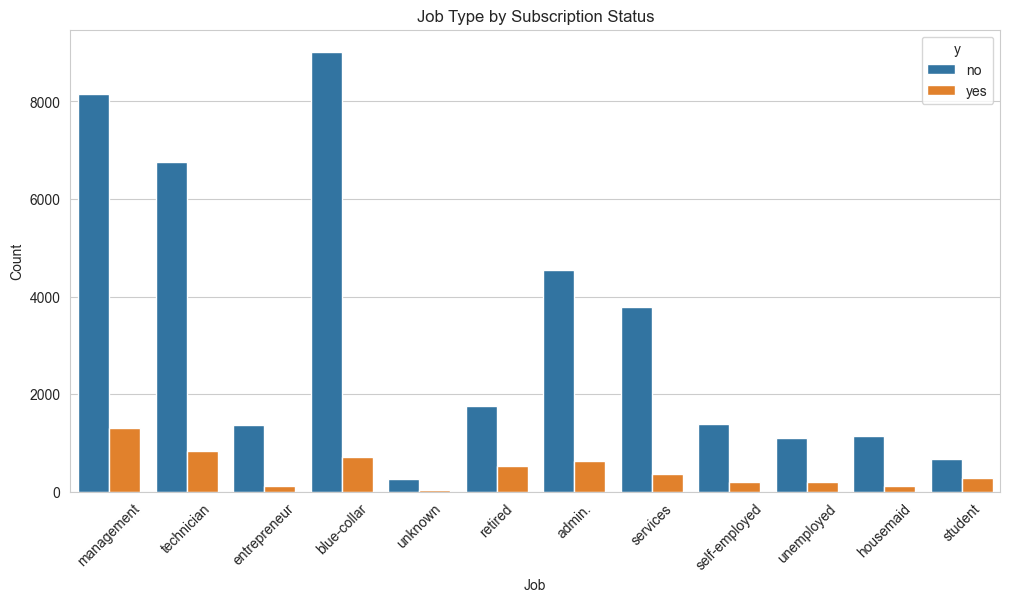

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='job',
    hue='y'
)

plt.title('Job Type by Subscription Status')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

In [16]:
pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
job,,
admin.,87.797331,12.202669
blue-collar,92.725031,7.274969
entrepreneur,91.728312,8.271688
housemaid,91.209677,8.790323
management,86.244449,13.755551
retired,77.208481,22.791519
self-employed,88.157061,11.842939
services,91.116996,8.883004
student,71.321962,28.678038


### Insight: Job vs Term Deposit Subscription

Subscription rates vary considerably across occupation groups.

- Students have the highest subscription rate, with approximately **28.7%** subscribing to a term deposit.
- Retired customers also show a relatively high subscription rate at **22.8%**.
- Unemployed customers have a subscription rate of **15.5%**, which is above the overall average.
- Customers working in management positions exhibit a subscription rate of **13.8%**.
- Blue-collar workers have one of the lowest subscription rates, with only **7.3%** subscribing.

These findings suggest that occupation may play an important role in predicting customer interest in term deposit products. Students and retired customers appear to be more responsive to marketing campaigns, while blue-collar and entrepreneurial segments show lower conversion rates.

## Balance vs Subscription

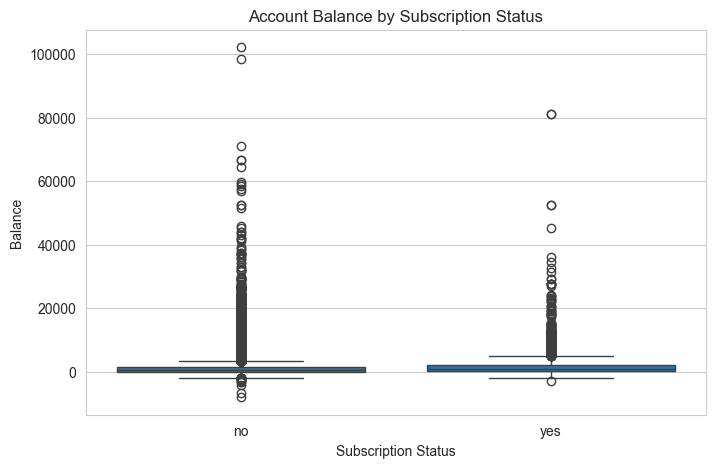

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='y',
    y='balance'
)

plt.title('Account Balance by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Balance')

plt.show()

In [18]:
df.groupby('y')['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,1303.714969,2974.195473,-8019.0,58.0,417.0,1345.0,102127.0
yes,5289.0,1804.267915,3501.104777,-3058.0,210.0,733.0,2159.0,81204.0


### Insight: Account Balance vs Term Deposit Subscription

Customers who subscribed to a term deposit generally maintain higher account balances compared to those who did not subscribe.

The median account balance for subscribers is **733**, compared to **417** for non-subscribers. Similarly, the average balance of subscribers (**1,804**) is noticeably higher than that of non-subscribers (**1,304**).

Although substantial outliers are present in both groups, the overall distribution suggests that customers with larger account balances may be more willing or financially able to invest in term deposit products.

This indicates that account balance could be an important predictor in the subscription decision process and may provide valuable information for customer targeting strategies.

## Call Duration vs Term Deposit Subscription

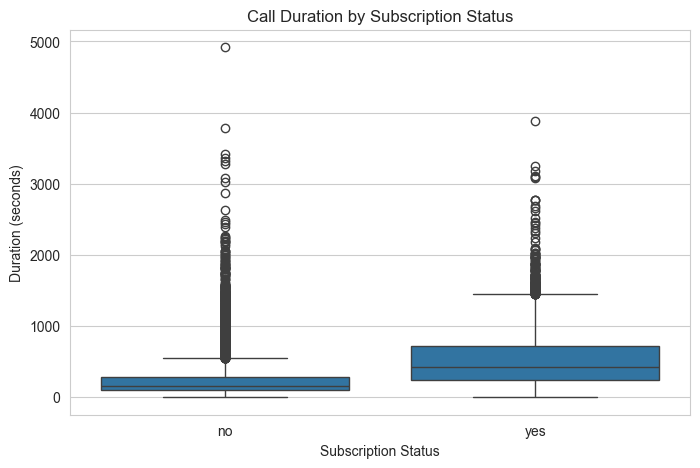

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='y',
    y='duration'
)

plt.title('Call Duration by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Duration (seconds)')

plt.show()

In [20]:
df.groupby('y')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


### Insight: Call Duration vs Term Deposit Subscription

Call duration shows a substantial difference between customers who subscribed and those who did not subscribe.

Customers who subscribed to a term deposit had a median call duration of **426 seconds**, compared to only **164 seconds** for non-subscribers. Similarly, the average call duration for subscribers (**537 seconds**) is more than twice that of non-subscribers (**221 seconds**).

The boxplot also reveals a clear separation between the two groups, suggesting a strong relationship between call duration and subscription outcomes.

This indicates that longer customer interactions are associated with a higher likelihood of successful term deposit subscriptions. Therefore, call duration is expected to be one of the most influential features in the predictive model.

## Previous Campaign Outcome vs Subscription

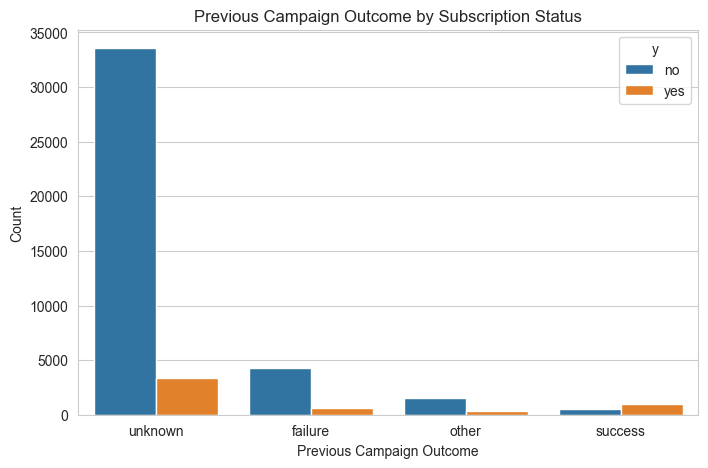

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='poutcome',
    hue='y'
)

plt.title('Previous Campaign Outcome by Subscription Status')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Count')

plt.show()

In [22]:
pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


### Insight: Previous Campaign Outcome vs Term Deposit Subscription

Previous campaign outcomes show a strong relationship with customer subscription behavior.

Customers who previously experienced a successful campaign outcome exhibit the highest subscription rate, with approximately **64.7%** subscribing to a term deposit. In contrast, customers with an unknown previous outcome show the lowest subscription rate at only **9.2%**.

Customers whose previous campaign resulted in failure have a subscription rate of **12.6%**, while those categorized as "other" have a subscription rate of **16.7%**.

These findings suggest that historical customer interactions are highly valuable for predicting future subscription behavior. Customers who responded positively in previous campaigns are significantly more likely to subscribe again, making previous campaign outcomes one of the most informative features for predictive modeling and marketing targeting.

## Contact Method vs Subscription

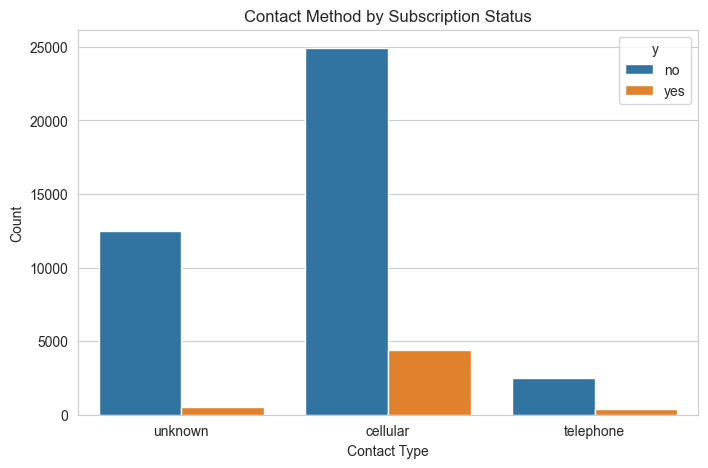

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='contact',
    hue='y'
)

plt.title('Contact Method by Subscription Status')
plt.xlabel('Contact Type')
plt.ylabel('Count')

plt.show()

In [24]:
pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
contact,,
cellular,85.081100,14.918900
telephone,86.579491,13.420509
unknown,95.929339,4.070661


### Insight: Contact Method vs Term Deposit Subscription

The method used to contact customers appears to influence subscription outcomes.

Customers contacted via **cellular phones** achieved the highest subscription rate at approximately **14.9%**, followed by **telephone contacts** at **13.4%**. In contrast, customers with an **unknown contact method** showed a substantially lower subscription rate of only **4.1%**.

These findings suggest that direct and clearly recorded communication channels are associated with better campaign performance. The extremely low conversion rate for customers with unknown contact methods may indicate incomplete customer records or less effective communication practices.

# 5. Data Preprocessing

## Create Data Copy

In [25]:
# Create a copy of the dataset
df_model = df.copy()

df_model.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Handling Unknown Values

In [31]:
categorical_cols = df_model.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df_model[col].value_counts())


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

## Target Encoding

In [27]:
# Encode target variable
df_model['y'] = df_model['y'].map({
    'no': 0,
    'yes': 1
})

df_model['y'].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

The target variable was converted into binary format, where:

- 0 = Customer did not subscribe
- 1 = Customer subscribed

This transformation is required for machine learning classification algorithms.

## Feature and Target Separation

In [28]:
X = df_model.drop('y', axis=1)
y = df_model['y']

print(X.shape)
print(y.shape)

(45211, 16)
(45211,)


## One-Hot Encoding

In [29]:
X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True


In [30]:
X.shape

(45211, 42)

Categorical features were transformed using One-Hot Encoding, increasing the feature space from 16 original predictors to 42 numerical features suitable for machine learning algorithms.

# 6. Feature Engineering

## Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

Stratified sampling was applied to preserve the original distribution of the target classes in both subsets.

In [33]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (36168, 42)
X_test shape : (9043, 42)
y_train shape: (36168,)
y_test shape : (9043,)


## Feature Scaling

Feature scaling was performed using StandardScaler to standardize feature values.

This step is particularly important for Logistic Regression because the algorithm is sensitive to differences in feature scales.

In [34]:
# Initialize scaler
scaler = StandardScaler()

In [36]:
# Fit scaler on training data
scaler.fit(X_train)

StandardScaler()

In [37]:
# Scale training data
X_train_scaled = scaler.transform(X_train)

In [38]:
# Scale testing data
X_test_scaled = scaler.transform(X_test)

In [39]:
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)

Scaled X_train shape: (36168, 42)
Scaled X_test shape : (9043, 42)


# 7. Model Development

## Logistic Regression

Logistic Regression is used as the baseline model for binary classification. The model estimates the probability that a customer will subscribe to a term deposit based on the available features.

In [40]:
# Initialize Logistic Regression model

logreg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [41]:
# Train Logistic Regression model

logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
# Make predictions on test data

y_pred_logreg = logreg.predict(X_test_scaled)

In [43]:
# Prediction probabilities

y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

# 8. Model Evaluation

## Logistic Regression

In [44]:
# Logistic Regression Performance Metrics

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_prob_logreg)

print("Accuracy :", accuracy_logreg)
print("Precision:", precision_logreg)
print("Recall   :", recall_logreg)
print("F1 Score :", f1_logreg)
print("ROC-AUC  :", roc_auc_logreg)

Accuracy : 0.901249585314608
Precision: 0.643979057591623
Recall   : 0.3487712665406427
F1 Score : 0.45248313917841815
ROC-AUC  : 0.9054433347971681


In [45]:
# Classification Report

print(classification_report(
    y_test,
    y_pred_logreg
))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



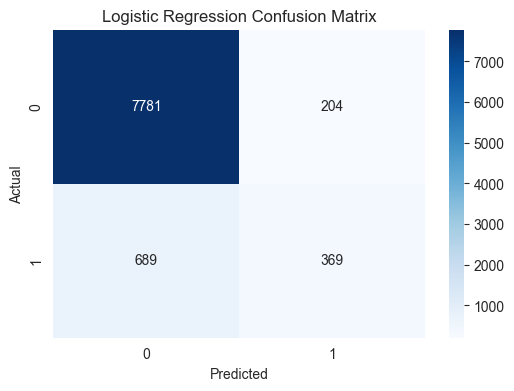

In [46]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_logreg
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Logistic Regression Evaluation

The Logistic Regression model achieved an accuracy of **90.12%** and a ROC-AUC score of **90.54%**, indicating strong overall discriminative performance.

However, the model achieved a recall of only **34.88%**, meaning that a substantial number of actual subscribers were not identified correctly. This behavior is expected due to the imbalanced nature of the dataset, where non-subscribers significantly outnumber subscribers.

Despite the relatively low recall, the model demonstrates strong precision (**64.40%**), suggesting that when the model predicts a customer will subscribe, the prediction is often correct.

## Random Forest

In [47]:
# Initialize Random Forest model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [48]:
# Train Random Forest model

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
# Make predictions

y_pred_rf = rf.predict(X_test)

In [50]:
# Prediction probabilities

y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [51]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Accuracy : 0.9048988167643481
Precision: 0.65814696485623
Recall   : 0.389413988657845
F1 Score : 0.48931116389548696
ROC-AUC  : 0.9272173250174891


## Model Comparison

In [52]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_logreg, accuracy_rf],
    'Precision': [precision_logreg, precision_rf],
    'Recall': [recall_logreg, recall_rf],
    'F1 Score': [f1_logreg, f1_rf],
    'ROC-AUC': [roc_auc_logreg, roc_auc_rf]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.901250,0.643979,0.348771,0.452483,0.905443
1,Random Forest,0.904899,0.658147,0.389414,0.489311,0.927217


### Model Comparison Insight

Both models achieved strong classification performance on the Bank Marketing dataset.

However, Random Forest consistently outperformed Logistic Regression across all evaluation metrics, including Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Therefore, Random Forest was selected as the final model for this project due to its superior predictive performance and stronger ability to distinguish between subscribers and non-subscribers.

# 9. Feature Importance

In [53]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,duration,0.274516
1,balance,0.101971
0,age,0.097557
2,day,0.087669
40,poutcome_success,0.052336
5,pdays,0.042412
4,campaign,0.039420
24,housing_yes,0.020915
6,previous,0.019245
27,contact_unknown,0.014198


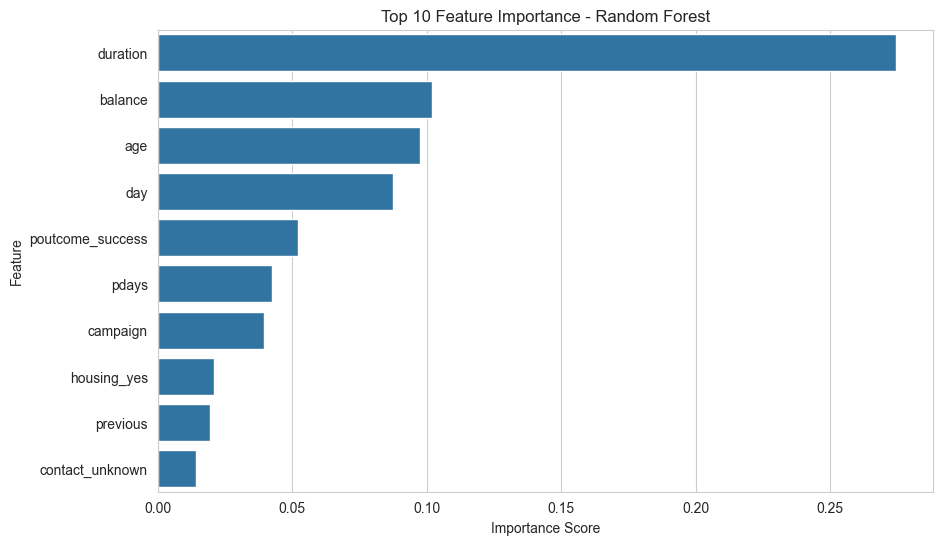

In [54]:
# Top 10 Feature Importance

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

### Feature Importance Analysis

The Random Forest model identified several key factors that influence customer subscription decisions.

The most important feature is **call duration (`duration`)**, contributing approximately 27.5% of the model's predictive power. This suggests that longer conversations are strongly associated with successful term deposit subscriptions.

Other influential features include:

- **Account balance (`balance`)**
- **Customer age (`age`)**
- **Contact day (`day`)**
- **Previous campaign success (`poutcome_success`)**
- **Days since previous contact (`pdays`)**
- **Number of campaign contacts (`campaign`)**

The prominence of previous campaign-related variables indicates that historical customer interactions play an important role in predicting future subscription behavior.

# 10. Business Insights

1. Customers who experienced a successful outcome in previous marketing campaigns are significantly more likely to subscribe again.

2. Call duration shows a strong relationship with subscription outcomes, indicating that customer engagement during conversations is an important factor.

3. Customers with higher account balances tend to subscribe more frequently, suggesting that financial capacity influences deposit investment decisions.

4. Subscription rates vary across occupations. Students and retired customers demonstrate higher conversion rates compared to several other job categories.

5. Contact methods matter. Customers contacted through cellular channels exhibit higher subscription rates than those with unknown contact methods.


# 11. Business Recommendations

1. Prioritize customers with a history of successful campaign responses, as they represent the highest probability conversion segment.

2. Focus marketing efforts on customer groups with historically higher subscription rates, such as students, retirees, and management professionals.

3. Improve customer contact data quality to reduce the number of records with unknown contact methods.

4. Develop call scripts and agent training programs aimed at increasing customer engagement during telemarketing conversations.

5. Consider customer financial indicators, such as account balance, when designing targeted deposit marketing campaigns.

# 12. Conclusion 

This project developed machine learning models to predict whether customers would subscribe to a term deposit product using the Bank Marketing Dataset.

After data preprocessing, exploratory analysis, feature engineering, and model development, both Logistic Regression and Random Forest achieved strong predictive performance. Random Forest outperformed Logistic Regression across all evaluation metrics and was selected as the final model.

The analysis revealed that call duration, account balance, customer age, and previous campaign outcomes are among the most influential factors affecting subscription decisions.

These findings can help banks improve marketing efficiency, prioritize high-potential customers, and optimize future telemarketing campaigns.